In [167]:
using Pkg
Pkg.activate("/home/chrisstrong/MRI_Driving/inverse-feedback-games/")
using iLQGames
import iLQGames: dx
using Plots
using ForwardDiff
using iLQGames:
    SystemTrajectory
using iLQGames:
    LinearSystem
using Infiltrator
using Optim
using LinearAlgebra
using Distributed
using Dates
using Statistics



  Activating project at `~/MRI_Driving/inverse-feedback-games`


In [ ]:
include("../src/diff_solver.jl")
include("../src/experiment_utils.jl") # NOTICE!! Many functions are defined there.

# added imports by Chris 
ENV["PYTHON"] = "/home/chrisstrong/miniconda3/envs/brain_env"
Pkg.build("PyCall")
using PyCall
import Base.length
using BenchmarkTools
using Flux
using ImageFiltering
using LazySets
using LinearAlgebra
using Plots
using Random

include("../src/geometric_utils.jl")

### Geometric utilities

#### Testing the geometric utilities

[ Info: Precompiling GR_jll [d2c73de3-f751-5644-a686-071e5b155ba9]
┌ Warning: Module Bzip2_jll with build ID fafbfcfd-a736-b2b9-000c-7e87fbe87307 is missing from the cache.
│ This may mean Bzip2_jll [6e34b625-4abd-537c-b88f-471c36dfa7a0] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:1793
[ Info: Skipping precompilation since __precompile__(false). Importing GR_jll [d2c73de3-f751-5644-a686-071e5b155ba9].
[ Info: Precompiling GLFW_jll [0656b61e-2033-5cc2-a64a-77c0f6c09b89]
┌ Warning: Module Xorg_libX11_jll with build ID fafbfcfd-80c0-547e-000c-7e898af205bb is missing from the cache.
│ This may mean Xorg_libX11_jll [4f6342f7-b3d2-589e-9d20-edeb45f2b2bc] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:1793
[ Info: Skipping precompilation since __precompile__(false). Importing GLFW_jll [0656b61e-2033-5cc2-a64a-77c0f6c09b89].
[ Info: Precompiling libdecor_jll [1183f4f0-6f2a-5f1a-908b-139f9cdfea6f]
┌ Warni

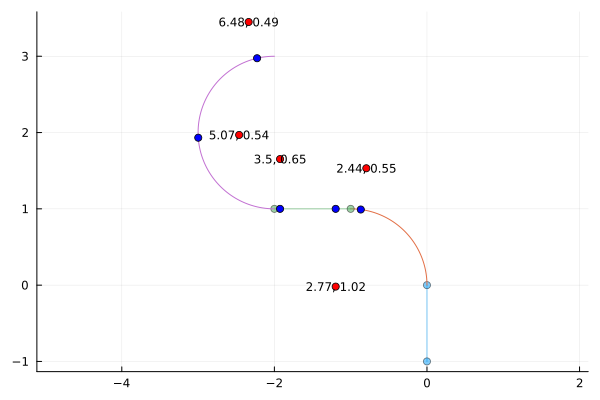

┌ Warning: Module Xorg_xcb_util_jll with build ID ffffffff-ffff-ffff-000c-7ed63e83104b is missing from the cache.
│ This may mean Xorg_xcb_util_jll [2def613f-5ad1-5310-b15b-b15d46f528f5] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:1793
[ Info: Skipping precompilation since __precompile__(false). Importing Xorg_xcb_util_renderutil_jll [0d47668e-0667-5a69-a72c-f761630bfb7e].


In [2]:
plot()
line_segment_1 = LineSegment([0., -1], [0., 0])
curve_1 = Arc([-1., 0], 1., 0., pi/2, false)
line_segment_2 = LineSegment([-1., 1], [-2., 1])
# turn right 
curve_2 = Arc([-2., 2], 1., 3*pi/2, pi/2, true)
trajectory = ListTrajectoryPlan([line_segment_1, curve_1, line_segment_2, curve_2])
visualize(trajectory)

# equal axis scale
plot!(aspect_ratio=:equal)


# benchmark time to project 1000 points onto the trajectory
points = [5 * rand(2) .- 1 for _ in 1:1000]
#@btime project(point, trajectory) setup=(point=3*rand(2) .- 1)

# generate random points, project onto trajectory 
num_points = 5
points = [[3 * rand(), 5 * rand()] - [3, 1] for _ in 1:num_points]

# for each point get its frenet coordinates and the point 
frenet_results = [project_frenet_coordinates(point, trajectory) for point in points]
distances_along_curve, distances_from_curve, projected_points = zip(frenet_results...)

for (point, distance_along_curve, distance_from_curve) in zip(points, distances_along_curve, distances_from_curve)
    scatter!([point[1]], [point[2]], color="red")
    # label each with distance along curve and distance from curve after rounding to 2 digits
    label = "$(round(distance_along_curve, digits=2)), $(round(distance_from_curve, digits=2))"
    annotate!([point[1]], [point[2]], text(label, 8, :black))
end

for point in projected_points
    scatter!([point[1]], [point[2]], color="blue")
end
# remove legend
plot!(legend=false)


### Data processing utils

In [3]:
function vehicle_index_to_col(index)
    return 6 + 5*(index - 1)
end

function pedestrian_index_to_col(index, k_closest_vehicles)
    return 6 + 5*k_closest_vehicles + 5*(index - 1)
end

function centerline_col(k_closest_vehicles, k_closest_pedestrians)
    return 6 + 5*k_closest_vehicles + 5*k_closest_pedestrians
end

function relu(x)
    return max.(0, x)
end

k_closest_vehicles = 15
k_closest_pedestrians = 0

0

### Visualization Utils

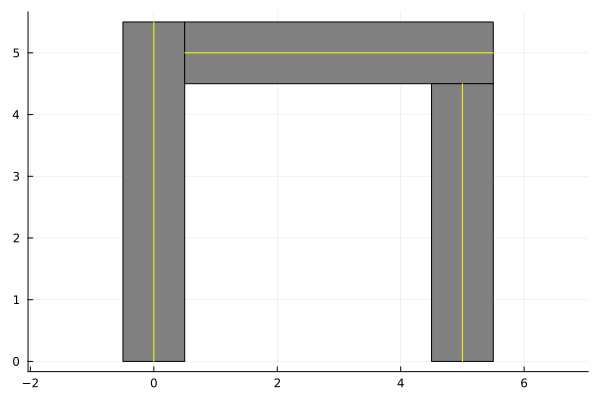

In [4]:
function visualize_road_segment(line_segment, road_width; color="gray", kwargs...)
    p, q = line_segment.p, line_segment.q
    v = p - q
    v = v / norm(v)

    perp = [0 -1; 1 0] * v
    rectangle_p1 = p + road_width / 2 * perp
    rectangle_p2 = p - road_width / 2 * perp
    rectangle_p3 = q - road_width / 2 * perp
    rectangle_p4 = q + road_width / 2 * perp
    plot!(polygon_from_points([rectangle_p1, rectangle_p2, rectangle_p3, rectangle_p4]); color=color, label="", kwargs...)
    
    # plot a yellow dashed line along the center and white lines along the edges 
    return plot!([p[1], q[1]], [p[2], q[2]], color="yellow", label="")
end

function visualize_map(centerlines, road_width=1200; kwargs...)
    for centerline in centerlines
        visualize_road_segment(centerline, road_width; kwargs...)
    end
    return plot!()
end

rectangle(w, h, x, y) = Shape(x + [0,w,w,0], y + [0,0,h,h])
polygon_from_points(points) = Shape([p[1] for p in points], [p[2] for p in points])

function visualize_road_from_key_points(key_points, road_width; kwargs...)
    # between each key point draw a rectangle of width road_width 
    for i in 1:length(key_points) - 1
        p1 = key_points[i]
        p2 = key_points[i + 1]

        v = p2 - p1
        v = v / norm(v)

        # extend line to be road_width / 2 longer 
        # except for the first and last lines
        if i > 1
            p1 = p1 + road_width / 2 * v
        end
        if i < length(key_points) - 1
            p2 = p2 + road_width / 2 * v
        end

        visualize_road_segment(LineSegment(p1, p2), road_width; kwargs...)
    end
    return plot!(aspect_ratio=:equal)
end

plot()
visualize_road_from_key_points([[0., 0], [0., 5], [5., 5], [5., 0]], 1.0, color="gray")

### Loading actual data

Load the trajectories

In [5]:
py"""
import pickle
 
def load_pickle(fpath):
    with open(fpath, "rb") as f:
        data = pickle.load(f)
    return data
"""

load_pickle = py"load_pickle"

train_demonstrations_turns = load_pickle("/data/fmri/full_dataset/SP/generated/demonstrations/train_demonstrations_turns_k_closest_vehicles=15_k_closest_pedestrians=0.pkl")
train_point_sequences = load_pickle("/data/fmri/full_dataset/SP/generated/demonstrations/train_point_sequences.pkl")

# # also load the ones that are just straights 
# train_demonstrations = load_pickle("/data/fmri/full_dataset/SP/generated/demonstrations/train_demonstrations_k_closest_vehicles=15_k_closest_pedestrians=0.pkl")

94-element Vector{Vector{Vector{Float64}}}:
 [[72424.5, 54220.0], [42719.0, 54220.0], [42719.0, 10586.5]]
 [[42719.0, 9680.46], [42719.0, 1260.14]]
 [[0.0, 25913.6], [0.0, 40152.3]]
 [[2040.33, 41076.0], [8215.0, 41076.0], [8215.0, 32986.3]]
 [[8215.0, 30236.5], [8215.0, 25467.0], [16430.0, 25467.0], [16430.0, 46931.3]]
 [[16430.0, 47686.6], [16430.0, 25467.0], [25798.5, 25467.0]]
 [[26868.0, 25467.0], [8215.0, 25467.0], [8215.0, 28602.2]]
 [[8215.0, 31415.3], [8215.0, 32860.0], [16430.0, 32860.0], [16430.0, 25467.0], [1118.29, 25467.0]]
 [[0.0, 26362.1], [0.0, 28075.0]]
 [[0.0, 29180.700000000004], [0.0, 0.0], [10194.2, 0.0]]
 [[10090.1, 0.0], [0.0, 0.0], [0.0, 33194.09999999999]]
 [[0.0, 36963.8], [0.0, 41076.0], [16430.0, 41076.0], [16430.0, 39118.6]]
 [[16430.0, 38192.8], [16430.0, 54220.0], [18264.4, 54220.0]]
 ⋮
 [[5237.09, 91188.0], [19716.0, 91188.0], [19716.0, 78865.0], [26288.0, 78865.0], [26288.0, 54220.0], [40580.1, 54220.0]]
 [[41359.299999999996, 54220.0], [42719.0, 54220

Load centerlines

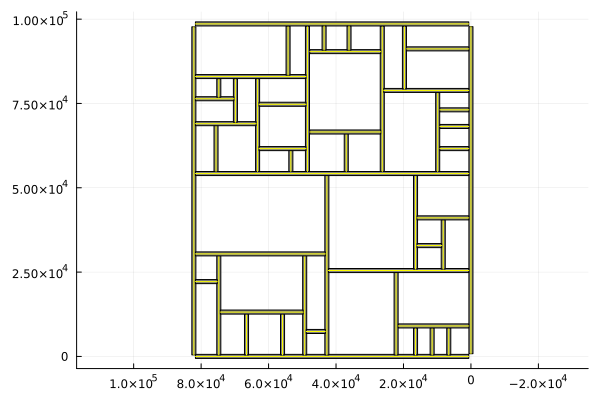

In [6]:
using NPZ
centerline_filename = "/data/fmri/full_dataset/map_centerlines.npz"
centerlines = npzread(centerline_filename)["lines"]
centerlines = [LineSegment(centerlines[i, 1, :], centerlines[i, 2, :]) for i in 1:size(centerlines, 1)]

plot()
visualize_map(centerlines, 1200, color="gray")
plot!(aspect_ratio=:equal, xflip=true)

Rescaling data

In [7]:
# Set some parameters
road_width_cm = 1200
scaling_factor = 2000

# Rescale the map
scaled_centerlines = [LineSegment(centerline.p / scaling_factor, centerline.q / scaling_factor) for centerline in centerlines]

# Rescale the train demonstration states 
train_demonstrations_turns_states = [train_demonstration[1] for train_demonstration in train_demonstrations_turns]

indices_to_scale = [1, 2, 4, 5] # x, y, v, a
for j = 1:k_closest_vehicles
    cur_col = vehicle_index_to_col(j)
    append!(indices_to_scale, [cur_col, cur_col + 1, cur_col + 3, cur_col + 4])
end 
centerline_index = centerline_col(k_closest_vehicles, k_closest_pedestrians)
append!(indices_to_scale, [centerline_index, centerline_index + 1, centerline_index + 2, centerline_index + 3])

scaled_demonstration_states = deepcopy(train_demonstrations_turns_states)
for i = 1:length(train_demonstrations_turns_states)
    scaled_demonstration_states[i][:, indices_to_scale] /= scaling_factor
end

# Scale the train_point_sequences 
scaled_train_point_sequences = train_point_sequences / scaling_factor

# Scale the road width
scaled_road_width = road_width_cm / scaling_factor


0.6

In [8]:
# Pull out some data from the first run to use for testing and visualization 
key_points = scaled_train_point_sequences[1]
xs = scaled_demonstration_states[1][:, 1]
ys = scaled_demonstration_states[1][:, 2];

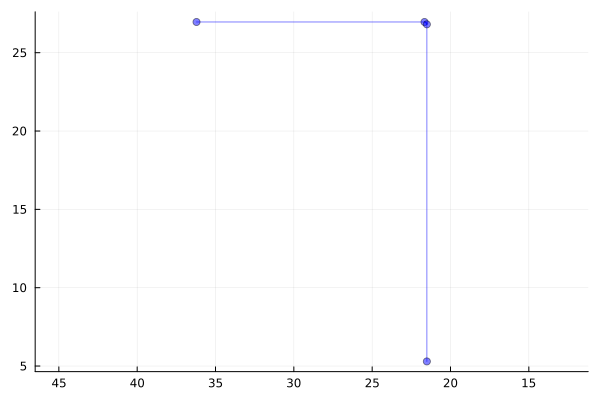

In [9]:
function road_shift_from_points(point1, point2, road_width)
    # Since we're using a left handed coordinate
    # if we're going in the positive x direction (left), the road shift is up in y 
    # if we're going in the negative x direction (right), the road shift is down in y 
    # if we're going in the positive y direction (up), the road shift is negative in x (right)
    # if we're going in the negative y direction (down), the road shift is positive in y (left)
    start_x, start_y, second_x, second_y = point1[1], point1[2], point2[1], point2[2]
    # assert x is constant or y is constant 
    @assert (start_x ≈ second_x || start_y ≈ second_y)

    if start_x < second_x
        road_shift = [0, road_width / 4]
    elseif start_x > second_x
        road_shift = [0, -road_width / 4]
    elseif start_y < second_y
        road_shift = [-road_width / 4, 0]
    elseif start_y > second_y
        road_shift = [road_width / 4, 0]
    end
    return road_shift
end

function shorten_segment(segment::LineSegment, dist_to_cut, direction="both")
    p, q = segment.p, segment.q
    v = q - p
    v = v / norm(v)
    if direction == "both"
        return LineSegment(p + v * dist_to_cut, q - v * dist_to_cut)
    elseif direction == "start"
        return LineSegment(p + v * dist_to_cut, q)
    elseif direction == "end"
        return LineSegment(p, q - v * dist_to_cut)
    else 
        error("Invalid direction")
    end
end 

function is_right_turn(direction_1, direction_2)
    # in left-handed coordinates, check to see if the turn is right. 
    # direction_1 should be the direction you start heading, and direction 2 should be the direction you end up heading 
    # if the cross product of the two vectors is positive, then it's a right turn
    return cross([direction_1; 0], [direction_2; 0])[3] > 0
end

# function trajectory_plan_from_key_points(key_points, road_width)
#     # go along alternating between straights and arcs, is that always right? 
#     # we'll note that we're in a left handed coordinate system, so left is more positive xs and right is 

#     trajectory_segments = []
    
#     # From the first two points get a line 
#     point1, point2 = key_points[1], key_points[2]
#     road_shift = road_shift_from_points(point1, point2, road_width)
#     line_segment = LineSegment(point1 + road_shift, point2 + road_shift)
#     # shorten the end of the line segment by 0.5*road_width 
#     line_segment = shorten_segment(line_segment, 0.5*road_width, "end")
#     push!(trajectory_segments, line_segment)

#     # now for each trio we'll add a curve then a straight 
#     for i = 1:(length(key_points) - 2)
#         point1, point2, point3 = key_points[i], key_points[i+1], key_points[i+2]

#         # get the vector from point1 to point2
#         direction_1 = (point1 - point2) / norm(point1 - point2)
#         # get the vector from point2 to point3
#         direction_2 = (point3 - point2) / norm(point3 - point2)

#         # add on the segment from point 2 to point 3 
#         road_shift = road_shift_from_points(point2, point3, road_width)
#         line_segment = LineSegment(point2 + road_shift, point3 + road_shift)
#         # shorten line segment on both sides by 0.5*road_width unless we're on the last index
#         # in which case we just shorten the start and not the end  
#         if i == length(key_points) - 2
#             line_segment = shorten_segment(line_segment, 0.5*road_width, "start")
#         else 
#             line_segment = shorten_segment(line_segment, 0.5*road_width, "both")
#         end

#         right_turn = is_right_turn(-direction_1, direction_2)
#         center_shift_amount = right_turn ? road_width / 2 : road_width / 4
#         circle_center = point2 + center_shift_amount * direction_1 + center_shift_amount * direction_2
        
#         # now see the angle from the end of the previous line segment to this circle 
#         previous_line_segment = trajectory_segments[end]
#         previous_end = previous_line_segment.q
#         start_angle = atan(previous_end[2] - circle_center[2], previous_end[1] - circle_center[1])
        
#         # now see the angle from the start of the next line segment to this circle 
#         next_line_segment = line_segment
#         next_start = next_line_segment.p
#         end_angle = atan(next_start[2] - circle_center[2], next_start[1] - circle_center[1])

#         clockwise = ~right_turn 
#         if clockwise 
#             # right turn in left-handed frame is a left turn, so larger radius 
#             circle_radius = 3 * road_width / 4
#         else 
#             circle_radius = road_width / 4
#         end
#         arc = Arc(circle_center, circle_radius, start_angle, end_angle, clockwise)
        
#         push!(trajectory_segments, arc)
#         push!(trajectory_segments, line_segment)
#     end
    
#     return ListTrajectoryPlan(trajectory_segments)
# end 
function trajectory_plan_from_key_points(key_points, road_width)
    # go along alternating between straights and arcs, is that always right? 
    # we'll note that we're in a left handed coordinate system, so left is more positive xs and right is 
    trajectory_segments = []
    
    # From the first two points get a line 
    point1, point2 = key_points[1], key_points[2]
    road_shift = road_shift_from_points(point1, point2, road_width)
    line_segment = LineSegment(point1 + road_shift, point2 + road_shift)
    # shorten the end of the line segment by 0.5*road_width 
    line_segment = shorten_segment(line_segment, 0.5*road_width, "end")
    push!(trajectory_segments, line_segment)

    # now for each trio we'll add a curve then a straight 
    for i = 1:(length(key_points) - 2)
        point1, point2, point3 = key_points[i], key_points[i+1], key_points[i+2]

        # get the vector from point1 to point2
        direction_1 = (point2 - point1) / norm(point1 - point2)
        # get the vector from point2 to point3
        direction_2 = (point3 - point2) / norm(point3 - point2)

        # add on the segment from point 2 to point 3 
        road_shift = road_shift_from_points(point2, point3, road_width)
        line_segment = LineSegment(point2 + road_shift, point3 + road_shift)
        # shorten line segment on both sides by 0.5*road_width unless we're on the last index
        # in which case we just shorten the start and not the end  
        if i == length(key_points) - 2
            line_segment = shorten_segment(line_segment, 0.5*road_width, "start")
        else 
            line_segment = shorten_segment(line_segment, 0.5*road_width, "both")
        end

        right_turn = is_right_turn(-direction_1, direction_2)
        center_shift_amount = road_width / 2 # shift from center or road point to the center of circle    #right_turn ? road_width / 4 : road_width / 2 # 
        circle_center = point2 - center_shift_amount * direction_1 + center_shift_amount * direction_2 # point2 - center_shift_amount * direction_1 + center_shift_amount * direction_2
        
        # now see the angle from the end of the previous line segment to this circle 
        previous_line_segment = trajectory_segments[end]

        previous_end = previous_line_segment.q
        start_angle = atan(previous_end[2] - circle_center[2], previous_end[1] - circle_center[1])
        
        # now see the angle from the start of the next line segment to this circle 
        next_line_segment = line_segment
        next_start = next_line_segment.p
        end_angle = atan(next_start[2] - circle_center[2], next_start[1] - circle_center[1])

        clockwise = right_turn 
        circle_radius = right_turn ? road_width * 3/4 : road_width / 4# in left-handed coordinate system right turns have larger radius 
        arc = Arc(circle_center, circle_radius, start_angle, end_angle, clockwise)
        
        push!(trajectory_segments, arc)
        push!(trajectory_segments, line_segment)
    end
    
    return ListTrajectoryPlan(trajectory_segments)
end 



plot()
# plot the trajectory and key points 
visualize_road_from_key_points(key_points, scaled_road_width)
plot!(xs, ys, color="red", label="")
#scatter!(key_xs, key_ys, color="blue", label="")

# now visualize the plan 
plot()
trajectory_plan = trajectory_plan_from_key_points(key_points, scaled_road_width)
visualize(trajectory_plan, color="blue")

# axis equal 
plot!(aspect_ratio=:equal, xflip=true)
# set x limits and y limits 
# plot!(xlims=(40, 60), ylims=(45, 55))

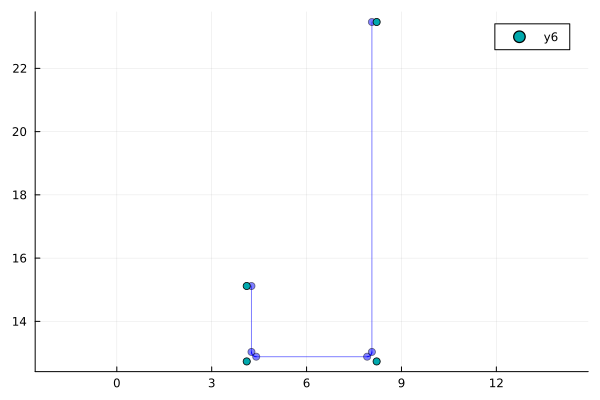

In [10]:
key_points = [[4.1075, 15.11825], [4.1075, 12.7335], [8.215, 12.7335], [8.215, 23.46565]]
trajectory_plan = trajectory_plan_from_key_points(key_points[1:4], scaled_road_width)
plot()
visualize(trajectory_plan, color="blue")
scatter!([point[1] for point in key_points], [point[2] for point in key_points], aspect_ratio=:equal)


┌ Info: Saved animation to 
└   fn = "/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/trajectory_from_data.gif"


Plots.AnimatedGif("/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/trajectory_from_data.gif")
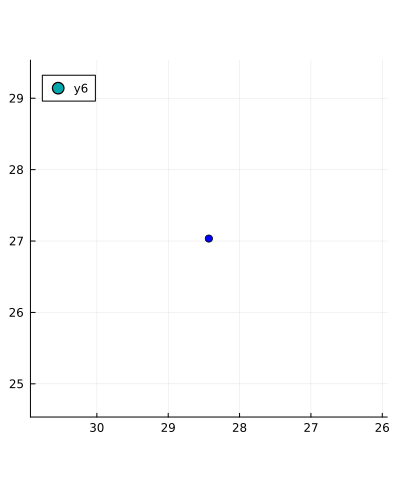

In [11]:
# animate the trajectory on the trajectory plan 
width_around_car = 5000 / scaling_factor 
height_around_car = 5000 / scaling_factor

anim=@animate for t in 500:5:900
    visualize_road_from_key_points(key_points, scaled_road_width, color="gray")

    # plot with a single circle the current location 
    scatter!([xs[t]], [ys[t]], color="blue", label="")

    # plot the plan 
    visualize(trajectory_plan, color="blue")

    plot!(size=(400,500))
    plot!(aspect_ratio=:equal, legend=:topleft, xflip=true)
    # set x limits and y limits
    plot!(xlims=(xs[t] - width_around_car, xs[t] + width_around_car), ylims=(ys[t] - height_around_car, ys[t] + height_around_car))
end
gif(anim, "visualizations/trajectory_from_data.gif", fps = 10)

┌ Info: Saved animation to 
└   fn = "/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/ego_trajectory.gif"


Plots.AnimatedGif("/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/ego_trajectory.gif")
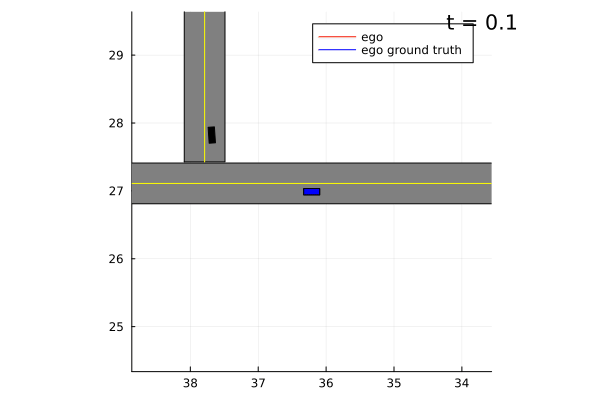

In [12]:
function plot_car_at_state(x, y, heading, velocity; width=185/scaling_factor, height=470/scaling_factor, color="black", kwargs...)
    # plot a rectangle at x, y, with given heading 

    front_right = [x + height / 2 * cos(heading) + width / 2 * cos(pi/2 - heading), y + height / 2 * sin(heading) - width / 2 * sin(pi/2 - heading)]
    front_left = [x + height / 2 * cos(heading) - width / 2 * cos(pi/2 - heading), y + height / 2 * sin(heading) + width / 2 * sin(pi/2 - heading)]
    back_left = [x - height / 2 * cos(heading) - width / 2 * cos(pi/2 - heading), y - height / 2 * sin(heading) + width / 2 * sin(pi/2 - heading)]
    back_right = [x - height / 2 * cos(heading) + width / 2 * cos(pi/2 - heading), y - height / 2 * sin(heading) - width / 2 * sin(pi/2 - heading)]
    
    # plot rectangle 
    plot!(polygon_from_points([front_right, front_left, back_left, back_right]), color=color, label="", kwargs...)
    # plot arrow from center in direction of heading 
    arrow_length = height*1.5
    arrow_delta_x = arrow_length * cos(heading)
    arrow_delta_y = arrow_length * sin(heading)
    #return quiver!([x], [y], quiver=([arrow_delta_x], [arrow_delta_y]), color=color, label="", kwargs...)
    #return plot!([x + arrow_delta_x, x], [y + arrow_delta_y, y], color=color, arrow=false, label="", kwargs...)
    return plot!()
end

function animate_trajectories(trajectories, colors, labels, demonstration, trajectory_plan, road_width, centerlines; time_spacing=5, field_of_view=5000, k_closest_vehicles=15, kwargs...)
    """
    trajectories: list of trajectories, each of which are a num_times x 4 array with x, y, heading, v
    """
    ego_states = demonstration[:, 1:4]

    # plot the vehicles from the trajectories
    anim = @animate for t = 1:time_spacing:size(demonstration, 1)
        plot(aspect_ratio=:equal, xflip=true)
        visualize_map(centerlines, road_width)
        # plot the trajectories 
        for (i, trajectory) in enumerate(trajectories)
            x, y, heading, v = trajectory[t, :]
            color = colors[i]
            label = labels[i]
            plot_car_at_state(x, y, heading, v, color=color)
            # also plot their trajectory so far
            plot!(trajectory[1:t, 1], trajectory[1:t, 2], color=color, label=label)
        end

        # visualize the trajectory plan 
        visualize(trajectory_plan, color="black")

        # plot the ground truth 
        x, y, heading, v = ego_states[t, :]
        plot_car_at_state(x, y, heading, v, color="blue")
        plot!(ego_states[1:t, 1], ego_states[1:t, 2], color="blue", label="ego ground truth")

        # plot the other vehicles 
        for i in 1:k_closest_vehicles
            other_x, other_y, other_heading, other_v = demonstration[t, vehicle_index_to_col(i):vehicle_index_to_col(i) + 3]
            plot_car_at_state(other_x, other_y, other_heading, other_v, color="black")
        end

        # set x limit based on the ego vehicle
        xlims = [x - field_of_view / 2, x + field_of_view / 2]
        ylims = [y - field_of_view / 2, y + field_of_view / 2]
        plot!(xlim=xlims, ylim=ylims)

        # add text label on the side showing t rounded to 2 digits  
        text_label = "t = $(round(t/15, digits=1))"
        annotate!(xlims[1], ylims[2], text_label)
    end
    return anim
end

demo = scaled_demonstration_states[1]
ego_traj = demo[:, 1:4]

trajectory_plan = trajectory_plan_from_key_points(key_points, scaled_road_width)
anim = animate_trajectories([ego_traj], ["red"], ["ego"], demo, trajectory_plan, scaled_road_width, scaled_centerlines, field_of_view = 10000/scaling_factor, time_spacing=10)
gif(anim, "visualizations/ego_trajectory.gif", fps=10)

### Finding parameters as initial conditions

In [168]:
# Some baseline parameters
n_params_to_fit = 13
nx, nu, ΔT, game_horizon = 5+n_params_to_fit, 2, 1/15, 30

# Setup the dynamics 
angular_control_scaling = 1 # 3
velocity_control_scaling = 1 # 3

struct SingleUnicycleAugmentedTT <: ControlSystem{ΔT,nx,nu} end
# state: (px, py, phi, v)
dx(cs::SingleUnicycleAugmentedTT, x, u, t) = SVector(x[4]cos(x[3]), x[4]sin(x[3]), u[1] / angular_control_scaling, u[2] / velocity_control_scaling, 0.0, zeros(n_params_to_fit)...) # last element of state is the initial time 
dynamics = SingleUnicycleAugmentedTT()

# Other cost parameters
k_closest_vehicles_for_cost = 0
# ego_v_desired = 600 / scaling_factor 

# ego_weight_distance_along_curve = 0.02
# ego_weight_distance_from_curve = 10.0
# ego_weight_velocity = 5.0
# ego_weight_control_1 = 1.0 / (scaling_factor / 1000)^2 / (angular_control_scaling)^2
# ego_weight_control_2 = 1.0 / (scaling_factor / 1000)^2 / (velocity_control_scaling)^2

# ego_comfortable_distance = 900 / scaling_factor 
# scaling_distance_from_curve = 3.0
# comfortable_distance_sigmoid_scaling = 10.0

# ego_weight_distance = 1.0

# distance_from_curve_sigmoid_scaling = 30.0 
# distance_from_curve_sigmoid_center = 0.2

# grad: [0.015541904239820539, 0.033495314428013984, 3.7310457649647386e-5, 0.0007035514573461447, 0.0, 0.0, -0.004905184849759084, 2.9369973944833737e-5, -2.2637666114260647e-5, -0.0006035777038070444, 9.508400944270543e-6, -0.0018210735903533173]


# desired_velocity_sigmoid_scaling = 6.0
desired_velocity_sigmoid_threshold = 900 / scaling_factor


function generate_ego_cost(demo, key_points)

    trajectory_plan = trajectory_plan_from_key_points(key_points, scaled_road_width)
    
    function wrapper_fcn(point)
        dist_along_curve, dist_from_curve, _ = project_frenet_coordinates(point, trajectory_plan)
        return [dist_along_curve, dist_from_curve]
    end 
    

    function ego_vehicle_cost(g, x, u, t)
        println("t: ", t, " u: ", u)
        # cost for ego vehicle
        ego_x, ego_y, ego_phi, ego_v, start_time = x[1:5]

        # parameters 
        ego_v_desired, ego_weight_distance_along_curve, ego_weight_distance_from_curve, ego_weight_velocity, ego_weight_control_1,
        ego_weight_control_2, ego_comfortable_distance, scaling_distance_from_curve, comfortable_distance_sigmoid_scaling, ego_weight_distance,
        distance_from_curve_sigmoid_scaling, distance_from_curve_sigmoid_center, desired_velocity_sigmoid_scaling = x[6:18]
        
        println("sigmoid scaling: ", desired_velocity_sigmoid_scaling)

        
        # rescaling
        #     0.3 - small 
        #     0.02 - small 
        #    10.0 - large 
        #     5.0 - large 
        #     0.25 - small 
        #     0.25 - small 
        #     0.45 - small 
        #     3.0 - large 
        #    10.0 - large 
        #     1.0 - small 
        #    30.0 - large 
        #     0.2 - small 

        # ego_v_desired, ego_weight_distance_along_curve, ego_weight_distance_from_curve, ego_weight_velocity, ego_weight_control_1, 
        # ego_weight_control_2, ego_comfortable_distance, scaling_distance_from_curve, comfortable_distance_sigmoid_scaling, ego_weight_distance, 
        # distance_from_curve_sigmoid_scaling, distance_from_curve_sigmoid_center, desired_velocity_sigmoid_scaling, desired_velocity_sigmoid_threshold  = x[6:19]

        ego_distance_along_curve, ego_distance_from_curve = wrapper_fcn([ego_x, ego_y])
        cur_cost = 0
        # get index of this time step 
        # round t / delta T to an int 
        t_index = floor(Int, (start_time + t) / ΔT) + 1

        closest_car_in_front = Inf

        car_in_front_loc = nothing
        for i = 1:k_closest_vehicles_for_cost
            vehicle_col = vehicle_index_to_col(i)
            vehicle_x, vehicle_y, vehicle_theta, vehicle_v, vehicle_a = demo[t_index, vehicle_col:vehicle_col + 4]
            vehicle_distance_along_curve, vehicle_distance_from_curve = wrapper_fcn([vehicle_x, vehicle_y])
            if ego_distance_from_curve == nothing || vehicle_distance_from_curve == nothing || ego_distance_along_curve == nothing || vehicle_distance_along_curve == nothing
                println("ego dist: ", ego_distance_from_curve)
                println("vehicle dist: ", vehicle_distance_from_curve)
                println("ego dist along: ", ego_distance_along_curve)
                println("vehicle dist along: ", vehicle_distance_along_curve)

                println("vehicle x: ", vehicle_x)
                println("vehicle y: ", vehicle_y) 
                println("ego x, y: ", [ego_x, ego_y])
            end
            cur_distance = sqrt(scaling_distance_from_curve*(vehicle_distance_from_curve - ego_distance_from_curve)^2 + (vehicle_distance_along_curve - ego_distance_along_curve)^2)
            cur_cost += ego_weight_distance * (ego_comfortable_distance - cur_distance)^2 * sigmoid(comfortable_distance_sigmoid_scaling*(ego_comfortable_distance - cur_distance))  #relu(ego_comfortable_distance - cur_distance)^2
            # println("vehicle x, vehicle y: ", (vehicle_x, vehicle_y))
            # println("vehicle distance along curve, dist from curve: ", (vehicle_distance_along_curve, vehicle_distance_from_curve))
            # println("distanc: ", cur_distance)

            diff_along_curve = vehicle_distance_along_curve - ego_distance_along_curve
            # tell if the vehicle is in front of you: it's ahead along the curve, is facing forward, and is within a road width of the plan (maybe will catch some that are at Ts depending on their angle?)
            if diff_along_curve > 0 && (abs((vehicle_theta - ego_phi) % (2*pi)) < pi/4) && vehicle_distance_from_curve < road_width_cm/scaling_factor 
                if diff_along_curve < closest_car_in_front
                    car_in_front_loc = [vehicle_x, vehicle_y]
                end
                closest_car_in_front = min(closest_car_in_front, diff_along_curve)
            end
        end
        v_desired_modified = ego_v_desired * sigmoid(desired_velocity_sigmoid_scaling * (closest_car_in_front - desired_velocity_sigmoid_threshold)) # 1 / (1 + exp(-sigmoid_scaling*(closest_car_in_front - sigmoid_threshold))) * ego_v_desired 
        #v_desired_modified = ego_v_desired

        # cost includind distance along curve, distance from curve, speed, and control cost 
        distance_from_curve_component = ego_weight_distance_from_curve * ego_distance_from_curve^2 * sigmoid(distance_from_curve_sigmoid_scaling*(ego_distance_from_curve - distance_from_curve_sigmoid_center))

        cur_cost += -ego_weight_distance_along_curve * ego_distance_along_curve^2 + distance_from_curve_component + ego_weight_velocity * (ego_v - v_desired_modified)^2 + sum([ego_weight_control_1 ego_weight_control_2] .* (u.^2)) # ego_weight_control_1 * u[1]^2 +  ego_weight_control_2 * u[2]^2
        return cur_cost
    end

    return (FunctionPlayerCost(ego_vehicle_cost),)
end


generate_ego_cost (generic function with 1 method)

In [169]:
function loss(
    θ, 
    nominal_game,
    nominal_solver,
    demo,
    start_index, 
    obs_time_list, 
    obs_state_list, 
    obs_control_list,  
    debug_mode=false
    ) 
    # don't include the extra cost params in x0 yet 
    x0 = SVector(demo[start_index, 1:4]..., (start_index-1) * ΔT)
    expert_traj = demo[start_index:start_index + game_horizon - 1, :]

    extended_x0 = SVector{nx}(vcat(x0, θ)) # where we concatenate the cost parameters (with dual) to the initial state
    purified_x0 = SVector{nx}(vcat(x0, ForwardDiff.value.(θ))) # where we remove the dual number associated with the cost parameters
    # solve the nominal game under the current θ:
    nominal_converged, nominal_traj, nominal_strategies = solve(nominal_game, nominal_solver, purified_x0)

    println("nominal u: ", nominal_traj.u)

    if ~nominal_converged
        println("solver didn't converge")
        return -1
    end

    # derive the LQ approximation along the nominal trajectory under the current θ:
    lqg = Differentiable_Solvers.lq_approximation(nominal_game, nominal_traj, nominal_solver)
    # what is the local LQ policy?
    local_strategies = Differentiable_Solvers.solve_lq_game_FBNE(lqg)
    # evaluate the predicted trajectory under the current θ:
    traj = Differentiable_Solvers.trajectory(
        extended_x0, 
        nominal_game, 
        local_strategies, 
        nominal_traj
    )
    
    loss_value = sum([(traj.x[t][i] - expert_traj[t, i])^2 for t in 1:game_horizon for i = 1:2]) / game_horizon # only sum the positions 

    # just add the first step's loss
    # loss_value = sum((traj.x[2][1:2] - expert_traj[2][1:2]).^2)

    # expert_data = transpose(mapreduce(permutedims, vcat, Vector([Vector(expert_traj.u[t][obs_control_list]) for t in obs_time_list])))
    # prediction = transpose(mapreduce(permutedims, vcat, Vector([Vector(traj.u[t][obs_control_list]) for t in obs_time_list])))
    # loss_value = norm(expert_data - prediction)^2
    if debug_mode
        println("expert_data: ", expert_data)
        println("prediction: ", prediction)
        println("loss_value: ", loss_value)
        return loss_value, expert_data, prediction, nominal_converged, nominal_traj, traj, nominal_strategies, local_strategies
    else
        return loss_value
    end
end

# to run: loss(cur_θ, games[53], solvers[53], scaled_demonstration_states[53], 1488, 1:game_horizon, 1:nx, 1:nu)

function batch_loss(
    θ, 
    nominal_games,
    nominal_solvers,
    demos,
    demo_indices,
    start_indices,
    obs_time_list, 
    obs_state_list, 
    obs_control_list,  
    debug_mode=false
    )

    total = 0.0
    num_converged = 0 
    for (demo_index, start_index) in zip(demo_indices, start_indices)
        println("demo index: ", demo_index, " sample: ", start_index)
        cur_loss = loss(θ, nominal_games[demo_index], nominal_solvers[demo_index], demos[demo_index], start_index, obs_time_list, obs_state_list, obs_control_list, debug_mode)
        if cur_loss != -1 
            total += cur_loss 
            num_converged += 1 
        end
    end
    println(num_converged, " converged out of ", length(start_indices))
    return total / num_converged 
end 


batch_loss (generic function with 2 methods)

### Collecting the data and fitting on batches

#### Setting up the appropriate games to get run 

In [170]:
ego_vehicle_costs = [generate_ego_cost(demonstration, key_points) for (demonstration, key_points) in zip(scaled_demonstration_states, scaled_train_point_sequences)]
player_inputs = (SVector(1,2),) # NOTE: the input is a tuple of inputs for each player
games = [GeneralGame(game_horizon, player_inputs, dynamics, costs) for costs in ego_vehicle_costs]
solvers = [iLQSolver(game,max_scale_backtrack=40, max_elwise_diff_converged = 0.05, max_elwise_diff_step = 0.1, equilibrium_type="FBNE") for game in games];


#### Testing you can apply gradient descent at a single moment in time 

In [171]:
include("../src/geometric_utils.jl")

distance_and_projection (generic function with 1 method)

In [172]:
start_index = 100
θ_initial = [600/scaling_factor, 0.02, 10.0, 5.0, 1.0 / (scaling_factor / 1000)^2 / (angular_control_scaling)^2, 
            1.0 / (scaling_factor / 1000)^2 / (velocity_control_scaling)^2, 900 / scaling_factor, 3.0, 10.0, 1.0,
            30.0, 0.2, 6.0]
# θ_initial = [600/scaling_factor, 0.02, 10.0, 5.0, 1.0 / (scaling_factor / 1000)^2 / (angular_control_scaling)^2,
#              1.0 / (scaling_factor / 1000)^2 / (velocity_control_scaling)^2, 900 / scaling_factor, 3.0, 10.0, 1.0,
#              30.0, 0.2, 6.0, 900 / scaling_factor]

costs = generate_ego_cost(scaled_demonstration_states[1], scaled_train_point_sequences[1])
player_inputs = (SVector(1,2),) # NOTE: the input is a tuple of inputs for each player
g = GeneralGame(game_horizon, player_inputs, dynamics, costs)
x0 = SVector(demo[start_index, 1:4]..., (start_index-1) * ΔT)
solver = iLQSolver(g, max_scale_backtrack=5, max_elwise_diff_step=Inf, equilibrium_type="FBNE")
c, expert_traj, strategies = solve(g, solver, SVector{nx}(vcat(x0, θ_initial)))

# loss_val = loss(θ_initial, g, solver, demo, start_index, 1:game_horizon, 1:nx, 1:nu)
# grad = ForwardDiff.gradient(x -> loss(x, g, solver, demo, start_index, 1:game_horizon, 1:nx, 1:nu), θ_initial)


# println("loss: ", loss_val)
# println("grad: ", grad)

t: 0.0 u: [0.0, 0.0]
sigmoid scaling: Dual{ForwardDiff.Tag{iLQGames.var"#43#45"{FunctionPlayerCost{var"#ego_vehicle_cost#881"{Matrix{Float64}, var"#wrapper_fcn#880"{ListTrajectoryPlan}}}, GeneralGame{Int64, Tuple{SVector{2, Int64}}, SingleUnicycleAugmentedTT, Tuple{FunctionPlayerCost{var"#ego_vehicle_cost#881"{Matrix{Float64}, var"#wrapper_fcn#880"{ListTrajectoryPlan}}}}}, SVector{2, Float64}, Float64}, Float64}}(Dual{ForwardDiff.Tag{iLQGames.var"#43#45"{FunctionPlayerCost{var"#ego_vehicle_cost#881"{Matrix{Float64}, var"#wrapper_fcn#880"{ListTrajectoryPlan}}}, GeneralGame{Int64, Tuple{SVector{2, Int64}}, SingleUnicycleAugmentedTT, Tuple{FunctionPlayerCost{var"#ego_vehicle_cost#881"{Matrix{Float64}, var"#wrapper_fcn#880"{ListTrajectoryPlan}}}}}, SVector{2, Float64}, Float64}, Float64}}(6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0),Dual{ForwardDiff.Tag{iLQGames.var"#43#45"{FunctionPlayerCost{var"#ego_vehicle_cost#881"{Matrix{Float64}, var"#wrapper_fcn#880"{

LoadError: MethodError: no method matching ^(::Nothing, ::Int64)

[0mClosest candidates are:
[0m  ^([91m::Union{AbstractChar, AbstractString}[39m, ::Integer)
[0m[90m   @[39m [90mBase[39m [90mstrings/[39m[90m[4mbasic.jl:733[24m[39m
[0m  ^([91m::MathOptInterface.ScalarAffineFunction{T}[39m, ::Integer) where T
[0m[90m   @[39m [35mMathOptInterface[39m [90m~/.julia/packages/MathOptInterface/1fRdT/src/Utilities/[39m[90m[4mfunctions.jl:1809[24m[39m
[0m  ^([91m::ForwardDiff.Dual{Tx}[39m, ::Integer) where Tx
[0m[90m   @[39m [32mForwardDiff[39m [90m~/.julia/packages/ForwardDiff/QdStj/src/[39m[90m[4mdual.jl:144[24m[39m
[0m  ...


In [19]:
purified_x0 = SVector{nx}(vcat(x0, θ_initial)) # where we remove the dual number associated with the cost parameters
# solve the nominal game under the current θ:
nominal_converged, nominal_traj, nominal_strategies = solve(g, solver, purified_x0)


(true, SystemTrajectory{30, 0.06666666666666667, 17, 2, SizedVector{30, SVector{17, Float64}, Vector{SVector{17, Float64}}}, SizedVector{30, SVector{2, Float64}, Vector{SVector{2, Float64}}}}(SVector{17, Float64}[[36.21225, 26.9879, -3.1405629093311163, 0.0, 0.0, 0.3, 0.02, 10.0, 5.0, 0.25, 0.25, 0.45, 3.0, 10.0, 1.0, 30.0, 0.2], [36.209830122715, 26.98789721412372, -3.140380656096913, 0.07259636672541118, 0.0, 0.3, 0.02, 10.0, 5.0, 0.25, 0.25, 0.45, 3.0, 10.0, 1.0, 30.0, 0.2], [36.203192464268675, 26.987888523899844, -3.140202295704343, 0.1265335575840774, 0.0, 0.3, 0.02, 10.0, 5.0, 0.25, 0.25, 0.45, 3.0, 10.0, 1.0, 30.0, 0.2], [36.19342114724406, 26.98787406052005, -3.140030468634012, 0.16660627464019914, 0.0, 0.3, 0.02, 10.0, 5.0, 0.25, 0.25, 0.45, 3.0, 10.0, 1.0, 30.0, 0.2], [36.18132172319273, 26.987854142469242, -3.1398669163383026, 0.19637693913888096, 0.0, 0.3, 0.02, 10.0, 5.0, 0.25, 0.25, 0.45, 3.0, 10.0, 1.0, 30.0, 0.2], [36.16749276775866, 26.987829192256996, -3.139712732875

In [20]:
g = games[57]
solver = solvers[57]
demo = scaled_demonstration_states[57]
start_index = 168

#initial_θ_guess = [0.0]
initial_θ_guess = [600/scaling_factor, 0.02, 10.0, 5.0, 1.0 / (scaling_factor / 1000)^2 / (angular_control_scaling)^2,
             1.0 / (scaling_factor / 1000)^2 / (velocity_control_scaling)^2, 900 / scaling_factor, 3.0, 10.0, 1.0,
             30.0, 0.2, 6.0, 900 / scaling_factor ]
θ = initial_θ_guess

losses = []
θs = []
step_size = 0.01
for i = 1:5
    cur_loss = loss(θ, g, solver, demo, start_index, 1:game_horizon, 1:nx, 1:nu)
    push!(losses, cur_loss)
    push!(θs, θ)

    println("θ = ", θ, " loss = ", cur_loss)
    grad = ForwardDiff.gradient(x -> loss(x, g, solver, demo, start_index, 1:game_horizon, 1:nx, 1:nu), θ)
    θ = θ - grad * step_size
end

LoadError: DimensionMismatch: expected input array of length 17, got length 19

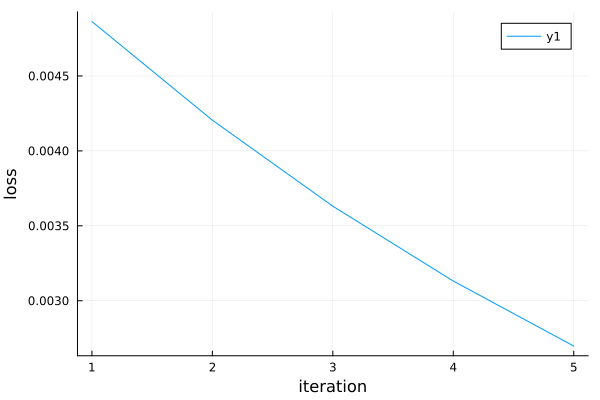

In [54]:
plot(losses, xlabel="iteration", ylabel="loss")

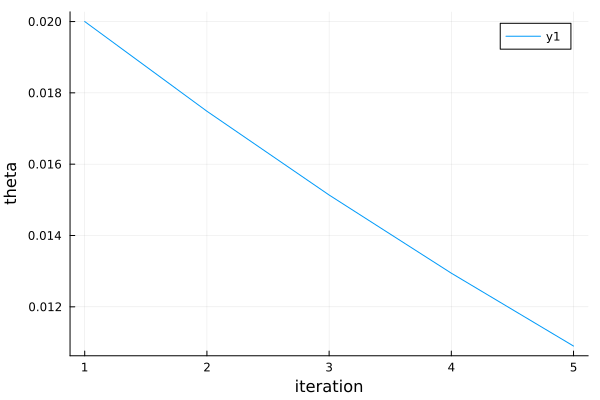

In [55]:
plot([θ[2] for θ in θs], xlabel="iteration", ylabel="theta")

#### gathering the data

In [21]:
length(scaled_demonstration_states)

94

In [22]:
demo_indices = []
start_indices = []

stride_length = 1

for i = 1:length(scaled_demonstration_states)
    demo_length = size(scaled_demonstration_states[i])[1]
    for j = 1: stride_length: (demo_length - game_horizon + 1)
        push!(demo_indices, i)
        push!(start_indices, j)
    end
end

data_loader = Flux.DataLoader(collect(zip(demo_indices, start_indices)), batchsize=20, shuffle=true)


4992-element DataLoader(::Vector{Tuple{Any, Any}}, shuffle=true, batchsize=20)
  with first element:
  20-element Vector{Tuple{Any, Any}}

In [23]:
start_time = time()

#theta_0 = [0.0]
# theta_0 = [600/scaling_factor, 0.02, 10.0, 5.0, 1.0 / (scaling_factor / 1000)^2 / (angular_control_scaling)^2,
# 1.0 / (scaling_factor / 1000)^2 / (velocity_control_scaling)^2, 900 / scaling_factor, 3.0, 10.0, 1.0,
# 30.0, 0.2, 6.0, 900 / scaling_factor]
theta_0 = [600/scaling_factor, 0.02, 10.0, 5.0, 1.0 / (scaling_factor / 1000)^2 / (angular_control_scaling)^2, 
1.0 / (scaling_factor / 1000)^2 / (velocity_control_scaling)^2, 900 / scaling_factor, 3.0, 10.0, 1.0,
30.0, 0.2]


cur_θ = theta_0
step_size = 0.01

thetas = []
losses = []
losses_theta_0 = []

max_batches = 50 

for (i, batch) in enumerate(data_loader)
    demo_indices = [data[1] for data in batch]
    start_indices = [data[2] for data in batch]

    println(demo_indices)
    println(start_indices)

    # compute the batch loss 
    
    cur_loss = batch_loss(cur_θ, games, solvers, scaled_demonstration_states, demo_indices, start_indices, 1:game_horizon, 1:nx, 1:nu)
    println("batch loss: ", cur_loss)

    loss_theta_0 = batch_loss(theta_0, games, solvers, scaled_demonstration_states, demo_indices, start_indices, 1:game_horizon, 1:nx, 1:nu)


    grad = ForwardDiff.gradient(x -> batch_loss(x,  games, solvers, scaled_demonstration_states, demo_indices, start_indices, 1:game_horizon, 1:nx, 1:nu), cur_θ)

    cur_θ = cur_θ - step_size * grad
    println("theta: ", cur_θ)
    println("grad: ", grad)
    # println("computing them in loop")
    # for j = 1:length(demo_indices)
    #     demo_index = demo_indices[j]
    #     start_index = start_indices[j]
    #     println("demo index: ", demo_index, " is in before: ", demo_index in demo_indices[1:j-1])
    #     temp_loss = loss(cur_θ, games[demo_index], solvers[demo_index], scaled_demonstration_states[demo_index], start_index, 1:game_horizon, 1:nx, 1:nu)
    #     println("time to ", j, " iteration: ", time() - start_time)
    # end
    println("time after batch ", i, " ", time() - start_time)

    push!(thetas, cur_θ)
    push!(losses, cur_loss)
    push!(losses_theta_0, loss_theta_0)

    if i > max_batches
        break 
    end
end


[58, 32, 19, 20, 56, 19, 72, 91, 28, 54, 77, 28, 18, 59, 28, 12, 23, 64, 93, 20]
[790, 858, 919, 634, 361, 573, 974, 938, 993, 1263, 193, 1511, 54, 170, 1663, 46, 299, 1730, 2109, 294]
demo index: 58 sample: 790
demo index: 32 sample: 858
demo index: 19 sample: 919
demo index: 20 sample: 634
demo index: 56 sample: 361
demo index: 19 sample: 573
demo index: 72 sample: 974
demo index: 91 sample: 938
demo index: 28 sample: 993
demo index: 54 sample: 1263
demo index: 77 sample: 193
demo index: 28 sample: 1511
demo index: 18 sample: 54
demo index: 59 sample: 170
demo index: 28 sample: 1663
demo index: 12 sample: 46
demo index: 23 sample: 299
demo index: 64 sample: 1730
demo index: 93 sample: 2109
demo index: 20 sample: 294
20 converged out of 20
batch loss: 0.013169632369487417
demo index: 58 sample: 790
demo index: 32 sample: 858
demo index: 19 sample: 919
demo index: 20 sample: 634
demo index: 56 sample: 361
demo index: 19 sample: 573
demo index: 72 sample: 974
demo index: 91 sample: 938


LoadError: InterruptException:

In [191]:
scaled_train_point_sequences[83]

6-element Vector{Vector{Float64}}:
 [2.618545, 45.594]
 [9.858, 45.594]
 [9.858, 39.4325]
 [13.144, 39.4325]
 [13.144, 27.11]
 [20.29005, 27.11]

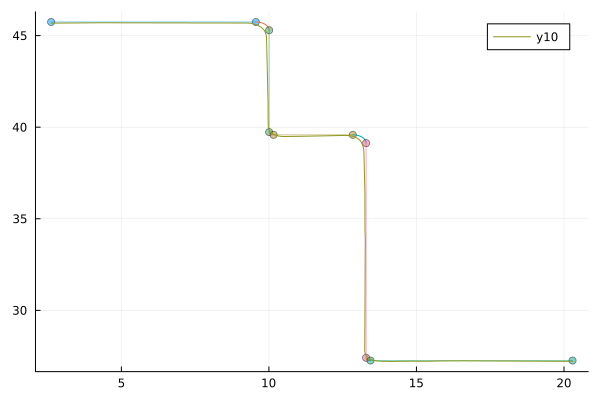

In [192]:
demo_index = 83
trajectory_plan = trajectory_plan_from_key_points(scaled_train_point_sequences[demo_index], scaled_road_width)
demo = scaled_demonstration_states[demo_index]    

function wrapper_fcn(point)
    dist_along_curve, dist_from_curve, _ = project_frenet_coordinates(point, trajectory_plan)
    return [dist_along_curve, dist_from_curve]
end 

project_frenet_coordinates([21.4589, 4.39977], trajectory_plan)

plot()
#visualize_map(scaled_centerlines, scaled_road_width)
visualize(trajectory_plan)
# scatter!([21.4589], [4.39977], aspect_ratio=:equal)
# plot!(xlims=[10, 30], ylims=[0, 15])
plot!(demo[:, 1], demo[:, 2])

In [188]:
trajectory_plan.subtrajectories[1]

LineSegment{Float64, Vector{Float64}}([2.618545, 45.744], [9.558, 45.744])

┌ Info: Saved animation to 
└   fn = "/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/ego_trajectory.gif"


Plots.AnimatedGif("/home/chrisstrong/MRI_Driving/inverse-feedback-games/examples/visualizations/ego_trajectory.gif")
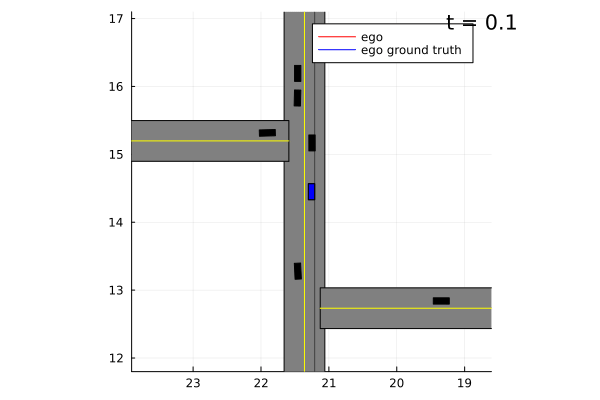

In [183]:
ego_traj = demo[580:end, 1:4]

anim = animate_trajectories([ego_traj], ["red"], ["ego"], demo[580:end, :], trajectory_plan, scaled_road_width, scaled_centerlines, field_of_view = 10000/scaling_factor, time_spacing=10)
gif(anim, "visualizations/ego_trajectory.gif", fps=10)

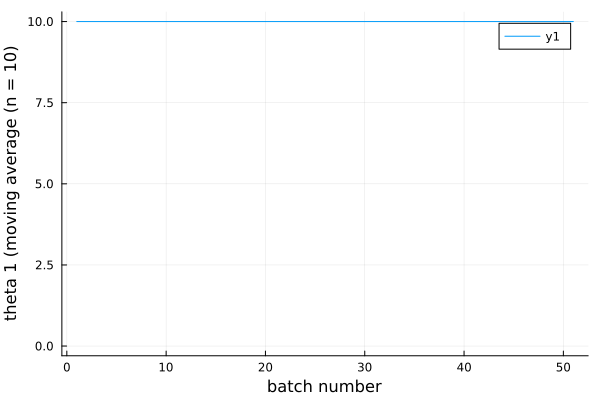

In [211]:
moving_average(vs,n) = [sum(@view vs[i:(i+n-1)])/n for i in 1:(length(vs)-(n-1))]
n_avg = 10

theta_1s = [theta[3] for theta in thetas]
plot(theta_1s, xlabel="batch number", ylabel= "theta 1 (moving average (n = "*string(n_avg)*")", ylim=[0, maximum(theta_1s)])

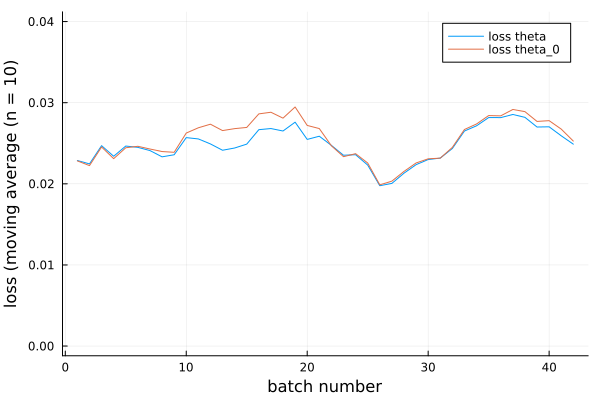

In [193]:

plot(moving_average(losses, n_avg), xlabel="batch number", ylabel="loss (moving average (n = "*string(n_avg)*")", label="loss theta")
plot!(moving_average(losses_theta_0, n_avg), label="loss theta_0")
plot!(ylims=[0, 0.04])

In [29]:
# check to see if initialize at each state in the demo if you can solve the problem if we'll still run into convergence issues. 
demo = scaled_demonstration_states[1]
solver = solvers[1]

num_steps = size(demo, 1) - game_horizon
print("num steps: ", num_steps)

for iteration = 1:num_steps
    cur_x = SVector(demo[iteration, 1:4]..., (iteration - 1) * ΔT, 0.015) 
    c, expert_traj, strategies = solve(games[1], solver, cur_x)
    if c == false 
        print(" ", iteration, " ")
        println("Solve failed, gave u: ", expert_traj.u[1])
    end
    #print("u: ", expert_traj.u[1])

end

num steps: 2003